In [1]:
import numpy as np
import pandas as pd
import hist
from hist import Hist
import awkward as ak
import json
import uproot
import math
from coffea import util
import pandas as pd
import pickle

import matplotlib.pyplot as plt
import mplhep
plt.style.use(mplhep.style.CMS)

In [2]:
out_dir = "../outfiles/Run3Summer22EE/cutflow"

era = "Run3Summer22EE"
        
lumis = {
    "Run3Summer22EE" : 1000 * 19.5 #5111.01917163, #1000 * 19.5
}

scale = {
    "Run3Summer22EE" : 1,
}

xs = {
    'QCD_PT-170to300' : 116000,
    'QCD_PT-300to470' : 7668,
    'QCD_PT-470to600' : 6.181e+02,
    'QCD_PT-600to800': 178,
    'QCD_PT-800to1000': 30.67,
    'QCD_PT-1000to1400':  9.024,
    'QCD_PT-1400to1800': 0.8037,
    'QCD_PT-1800to2400' : 0.1154,
    'QCD_PT-2400to3200': 0.007721,
    'Zto2Q-4Jets_HT-200to400' : 1111,
    'Zto2Q-4Jets_HT-400to600' : 124.3,
    'Zto2Q-4Jets_HT-600to800' : 27.89,
    'Zto2Q-4Jets_HT-800' : 14.53,
}

# Table of contents <a class="anchor" id="tbc"></a>

* [Plotting QCD distributions](#qcd)

# Plotting QCD distributions <a class="anchor" id="qcd"></a>
[TBC](#tbc)

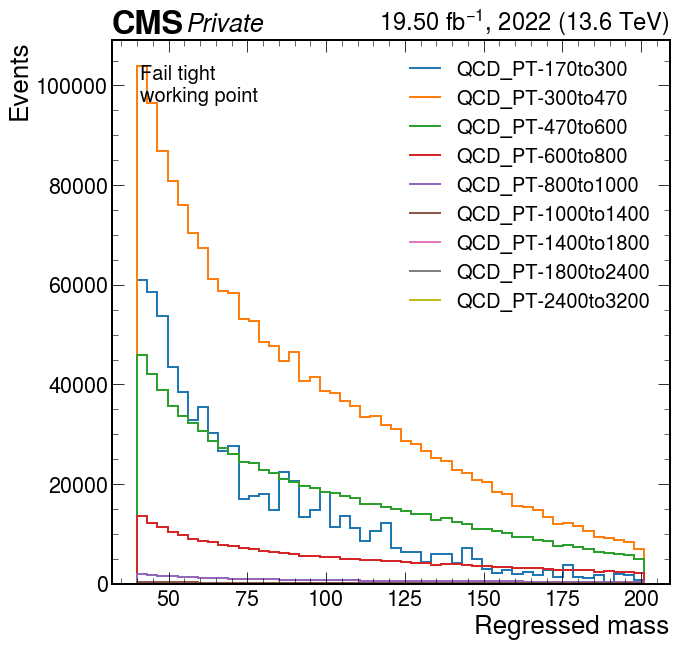

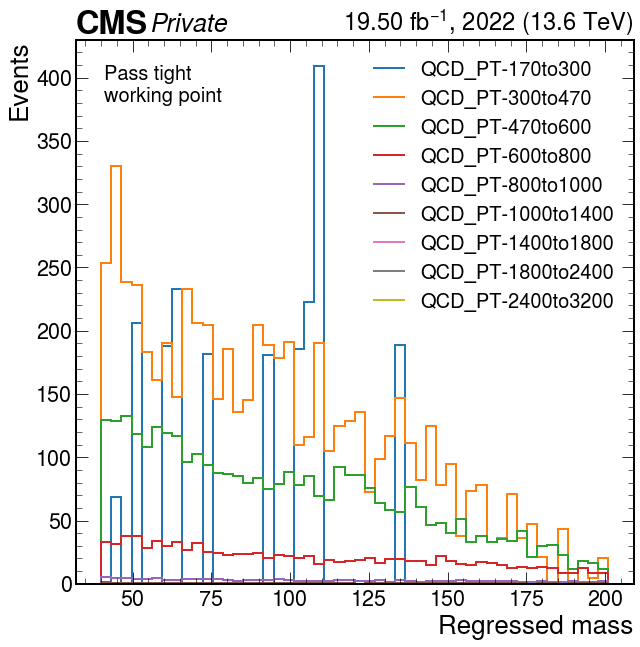

In [7]:
plt.style.use(mplhep.style.CMS)

mc = util.load(f"{out_dir}/dask_QCD.coffea")[0]
# "dataset" has to be first for the scaling to work
mc["cutflow"] = mc["cutflow"].project('dataset', 'reg', 'pt', 'disc', 'genflav', 'cut')

scale_lumi = {k: xs[k] * lumis[era] * scale[era] / w for k, w in mc['sumw'].items()}

for i, name in enumerate(mc["cutflow"].axes["dataset"]):
    mc["cutflow"].view(flow=True)[i] *= scale_lumi[name]

wps = {
    1 : "loose",
    2 : "medium",
    3 : "tight",
}

wp = 3

for region in ["Fail", "Pass"]:
    
    hs = []
    labels = []
    
    fig, (ax) = plt.subplots(
        1, 1, figsize=(10, 10),
    )
    fig.subplots_adjust(hspace=0.1)
    ax.set_ylabel("Events")

    for dataset in ['QCD_PT-170to300', 'QCD_PT-300to470', 'QCD_PT-470to600', 'QCD_PT-600to800', 'QCD_PT-800to1000', 'QCD_PT-1000to1400', 'QCD_PT-1400to1800', 'QCD_PT-1800to2400', 'QCD_PT-2400to3200']:
        
        h = mc["cutflow"].project("reg", "cut", "dataset", "disc", "genflav", "pt")[
            :, 5, hist.loc(dataset), :, 0:len:sum, 0:len:sum
        ]
        
        if "Pass" in region:
            h = h[:, wp:4:sum]
        else:
            h = h[:, 0:wp:sum]
            
        hs.append(h)
        labels.append(dataset)

    mplhep.histplot(
        hs,
        ax=ax,
        label=labels,
#         stack=True,
#         sort="y_r",
#         histtype="fill",
#         edgecolor="black",
        linewidth=2,
        yerr=False,
    )
    
    plt.text(0.05, 0.88, f"{region} {wps[wp]}\nworking point",
                fontsize=20,
                horizontalalignment='left',
                verticalalignment='bottom',
                transform=ax.transAxes
               )

    mplhep.cms.label(
            ax=ax, 
            data=True, 
            fontsize=25,
            label="Private",
            year=2022,
            lumi=f"{lumis[era]/1000:.2f}",
            com=13.6,
            )
    
    ax.legend(loc="upper right", fontsize=20)

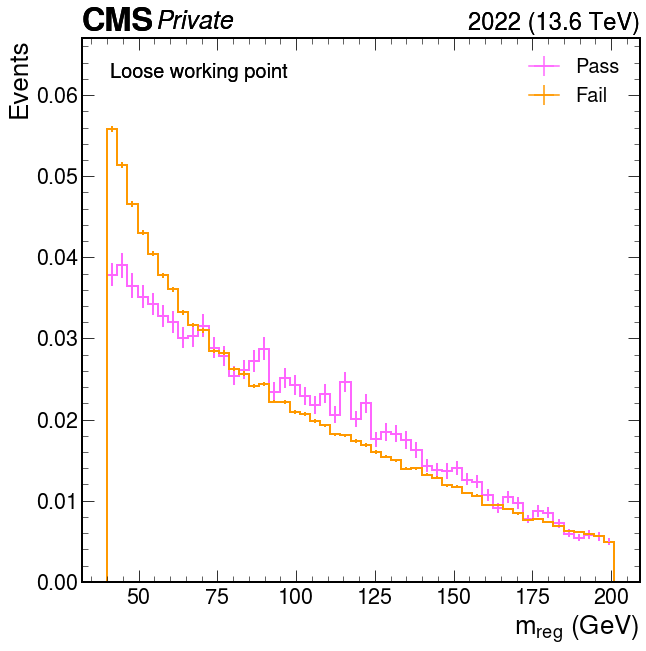

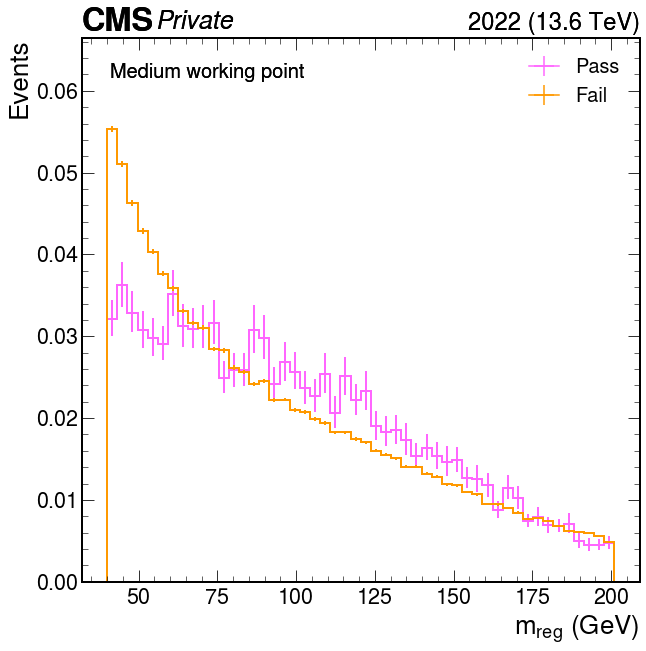

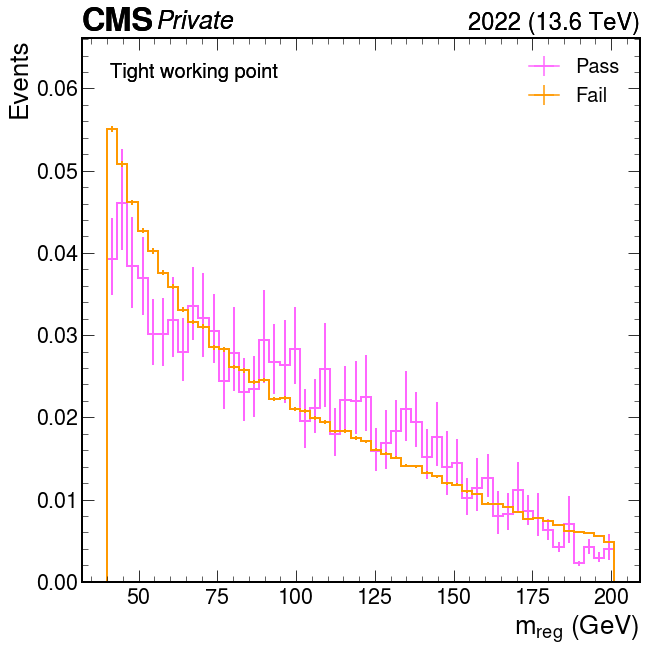

In [13]:
plt.style.use(mplhep.style.CMS)

mc = pickle.load(open(f'{out_dir}/mc.pkl','rb'))

wps = {
    1 : "Loose",
    2 : "Medium",
    3 : "Tight",
}

colours = {
    "Pass" : "#FF66FF",
    "Fail" : "#FF9900",
}

wp = 1

for wp in [1, 2, 3]:

    fig, (ax) = plt.subplots(
            1, 1, figsize=(10, 10),
        )
    fig.subplots_adjust(hspace=0.1)
    ax.set_ylabel("Events")
    ax.set_xlabel(r"$m_{reg}$ (GeV)")

    for region in ["Pass", "Fail"]:

        h = mc.project("reg", "cut", "process", "disc", "genflav", "pt")
        h = h[:, 5, hist.loc("QCD"), :, 0:len:sum, 0:len:sum]

        if "Pass" in region:
            h = h[:, wp:4:sum]
        else:
            h = h[:, 0:wp:sum]

        h = h[hist.rebin(1)]
        h = h / h.sum().value

        mplhep.histplot(
            h,
            ax=ax,
            label=f"{region}",
            linewidth=2,
            color=colours[region],
        )

        plt.text(0.05, 0.92, f"{wps[wp]} working point",
                    fontsize=20,
                    horizontalalignment='left',
                    verticalalignment='bottom',
                    transform=ax.transAxes
                   )

        mplhep.cms.label(
                ax=ax, 
                data=True, 
                fontsize=25,
                label="Private",
                year=2022,
#                 lumi=f"{lumis[era]/1000:.2f}",
                com=13.6,
                )

    ax.legend(loc="upper right", fontsize=20)

    ax.set_ylim(0, max(h.values()) * 1.2)
    
    fig.savefig("QCD_FP.pdf", bbox_inches='tight')